In [8]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [9]:
from PIL import Image
import numpy as np

img = Image.open("../data/raw/spatial/tissue_hires_image.png")
img_np = np.array(img)

print(img_np.shape)

(3886, 6000, 3)


In [10]:
import scanpy as sc

adata = sc.read("../data/processed/adata_slice_100.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 3332 × 3213
    obs: 'x', 'y', 'x_img', 'y_img'


In [11]:
PATCH_SIZE = 224

def extract_patch(image, x, y, patch_size=224):
    h, w, _ = image.shape
    
    x = int(x)
    y = int(y)
    
    half = patch_size // 2
    
    x1 = max(0, x - half)
    x2 = min(w, x + half)
    
    y1 = max(0, y - half)
    y2 = min(h, y + half)
    
    patch = image[y1:y2, x1:x2]
    
    # pad if needed (edge cases)
    if patch.shape[0] != patch_size or patch.shape[1] != patch_size:
        patch = np.pad(
            patch,
            (
                (0, patch_size - patch.shape[0]),
                (0, patch_size - patch.shape[1]),
                (0, 0)
            ),
            mode='constant'
        )
    
    return patch

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

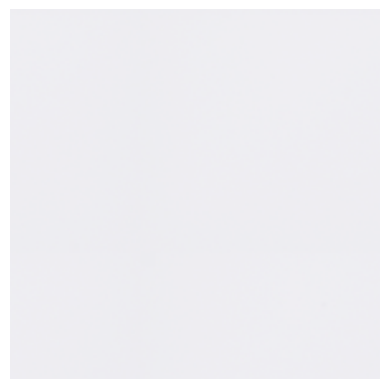

In [12]:
x = adata.obs["x_img"].iloc[0]
y = adata.obs["y_img"].iloc[0]

patch = extract_patch(img_np, x, y, 224)

import matplotlib.pyplot as plt
plt.imshow(patch)
plt.axis("off")

In [13]:
patches = []

for i in range(len(adata)):
    x = adata.obs["x_img"].iloc[i]
    y = adata.obs["y_img"].iloc[i]
    
    patch = extract_patch(img_np, x, y, 224)
    patches.append(patch)

patches = np.array(patches)

print(patches.shape)

(3332, 224, 224, 3)


In [14]:
np.save("../data/processed/patches.npy", patches)